In [1]:
import logging
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
from matplotlib.colors import XKCD_COLORS

In [ ]:
# --- Configuration ---
config = {
    'data_dir': "../derivatives",
    'raw_dir': "../ds000224",
    'roi_mask_path': "./Sphere_Mask.nii",
    'subj_prefix': "sub-MSC",
    'sess_prefix': "ses-func",
    'task_label': "task-memoryscenes",
    'space_label': "space-MNI152NLin2009cAsym",
    'bold_suffix': "desc-preproc_bold.nii.gz",
    'mask_suffix': "desc-brain_mask.nii.gz",
    'confounds_suffix': "desc-confounds_timeseries.tsv",
    'events_suffix': 'events.tsv',
    'output_dir_name': 'datasets', # Name for subdirectory
    'output_suffix': 'roi-fef_encoding-categorical_desc-simp_model_1.csv',
    'nilearn_defaults': {
         'standardize': 'zscore_sample',
         'detrend': True,
         'low_pass': 0.1,
         'high_pass': 0.01,
         't_r': 2.2
     },
     'hrf_model': 'spm'
}

# --- Usage Example in loop ---
# Instead of:
# p_brain = os.path.join(data_path, subj_pref+sub, ...)
# You'd use:
sub_id = f"{config['subj_prefix']}{sub}"
ses_id = f"{config['sess_prefix']}{ses}"
task_id = config['task_label']
space_id = config['space_label']

p_brain = os.path.join(config['data_dir'], sub_id, ses_id, 'func',
                       f"{sub_id}_{ses_id}_{task_id}_{space_id}_{config['bold_suffix']}")
# ... and so on for other paths and parameters

In [ ]:
import logging

# --- Basic Setup (do this once at the start) ---
logging.basicConfig(level=logging.INFO, # Set minimum level to show
                    format='%(asctime)s - %(levelname)s - %(message)s',
                    datefmt='%Y-%m-%d %H:%M:%S',
                    # filename='pipeline.log', # Uncomment to log to a file
                    # filemode='w' # 'w' to overwrite, 'a' to append
                   )

# --- Usage Example ---
logging.info(f"Starting processing for Subject {sub}, Session {ses}")

if not os.path.isfile(p_brain):
    logging.warning(f"Brain file not found for {sub}, {ses}. Skipping.") # Use WARNING for skips
    continue

try:
    bold_img = skull_strip(p_brain, p_mask)
    logging.debug("Skull stripping successful.") # DEBUG for detailed steps
except Exception as e:
    logging.error(f"Error during skull stripping for {sub}, {ses}: {e}") # ERROR for failures
    continue # Or handle error differently

# ... later ...
logging.info(f"Finished Subject {sub}, Session {ses}")

In [3]:
fdf = pd.read_csv("./full_fef_dataset1.csv", header=0, index_col=0)
fdf.head()

,scan_time,v0,v1,v2,v3,v4,v5,v6,v7,v8,...,v111,v112,v113,v114,v115,v116,v117,v118,v119,target
0,0.0,-1.357829e-07,-1.386015e-07,9.921290e-08,2.399383e-07,-2.166948e-07,-1.489032e-07,-1.082097e-07,3.818681e-08,2.981593e-07,...,2.133059e-08,3.909145e-07,-1.033122e-07,-2.027137e-08,1.377441e-07,-2.207919e-07,-4.686958e-09,-1.665084e-07,-4.525186e-07,nontask
1,2.2,8.909464e-07,9.094406e-07,-6.509904e-07,-1.574367e-06,1.421854e-06,9.770358e-07,7.100235e-07,-2.505648e-07,-1.956388e-06,...,-1.399618e-07,-2.565006e-06,6.778881e-07,1.330117e-07,-9.038149e-07,1.448738e-06,3.075332e-08,1.092554e-06,2.969224e-06,nontask
2,4.4,-3.170183e-06,-3.235989e-06,2.316367e-06,5.601944e-06,-5.059267e-06,-3.476508e-06,-2.526419e-06,8.915643e-07,6.961257e-06,...,4.980149e-07,9.126853e-06,-2.412075e-06,-4.732848e-07,3.215972e-06,-5.154925e-06,-1.094273e-07,-3.887546e-06,-1.056515e-05,nontask
3,6.6,8.196495e-06,8.366638e-06,-5.988958e-06,-1.448381e-05,1.308072e-05,8.988498e-06,6.532048e-06,-2.305136e-06,-1.799831e-05,...,-1.287616e-06,-2.359745e-05,6.236410e-06,1.223676e-06,-8.314883e-06,1.332804e-05,2.829237e-07,1.005124e-05,2.731616e-05,nontask
4,8.8,-1.727009e-05,-1.762858e-05,1.261879e-05,3.051751e-05,-2.756119e-05,-1.893885e-05,-1.376308e-05,4.856943e-06,3.792259e-05,...,2.713018e-06,4.972003e-05,-1.314017e-05,-2.578297e-06,1.751953e-05,-2.808230e-05,-5.961229e-07,-2.117804e-05,-5.755540e-05,nontask


In [4]:
fdf.target.value_counts()

target
mixed      4250
indoor     3145
outdoor    3018
nontask    1324
Name: count, dtype: int64

At this point, we do not know the answers to the following questions:
1. Do all the voxels contain relevant information?
2. Is this the best way of encoding the hemodynamic response function convolved with the experimental design into classes?
3. How do I incorporate the temporal relationships into this dataset in a meaningful way?

As seen above, the target column is not very well balanced. We will start by classifying this dataset as-is.

In [5]:
# First, let's convert the strings in the target column into categorical numerics.
fdf['target_numeric'] = fdf['target'].map({'mixed':4, 'outdoor':3, 'indoor':2, 'nontask':1})
fdf.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11737 entries, 0 to 11736
Columns: 123 entries, scan_time to target_numeric
dtypes: float64(121), int64(1), object(1)
memory usage: 11.1+ MB


---

In [6]:
x = fdf.drop(['target', 'target_numeric'], axis=1)
# x_norm = StandardScaler().fit_transform(x)
y = fdf['target_numeric']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

In [8]:
model_1 = KNeighborsClassifier(n_neighbors=500).fit(X_train,y_train)
y_m1 = model_1.predict(X_test)
acc_m1 = accuracy_score(y_test, y_m1)

In [9]:
acc_m1

0.45343554798409996

In [11]:
print(classification_report(y_test, y_m1))

              precision    recall  f1-score   support

           1       0.84      0.86      0.85       379
           2       0.39      0.20      0.26       941
           3       0.28      0.02      0.03       964
           4       0.41      0.86      0.56      1238

    accuracy                           0.45      3522
   macro avg       0.48      0.48      0.43      3522
weighted avg       0.41      0.45      0.37      3522



This accuracy isn't unexpected, and we know that the model is not learning about indoor vs outdoor--not really. Let's actually try a bunch of values of k to discover what value works best. We'll print the classification report for the best value.

In [12]:
k_vals = np.arange(50,1000,25)
acc_vals = np.zeros(len(k_vals))

for i,k in enumerate(k_vals):
    model = KNeighborsClassifier(n_neighbors=k).fit(X_train,y_train)
    y_m = model.predict(X_test)
    acc_vals[i] = accuracy_score(y_test, y_m)

Text(0.5, 1.0, 'Performance of KNN')

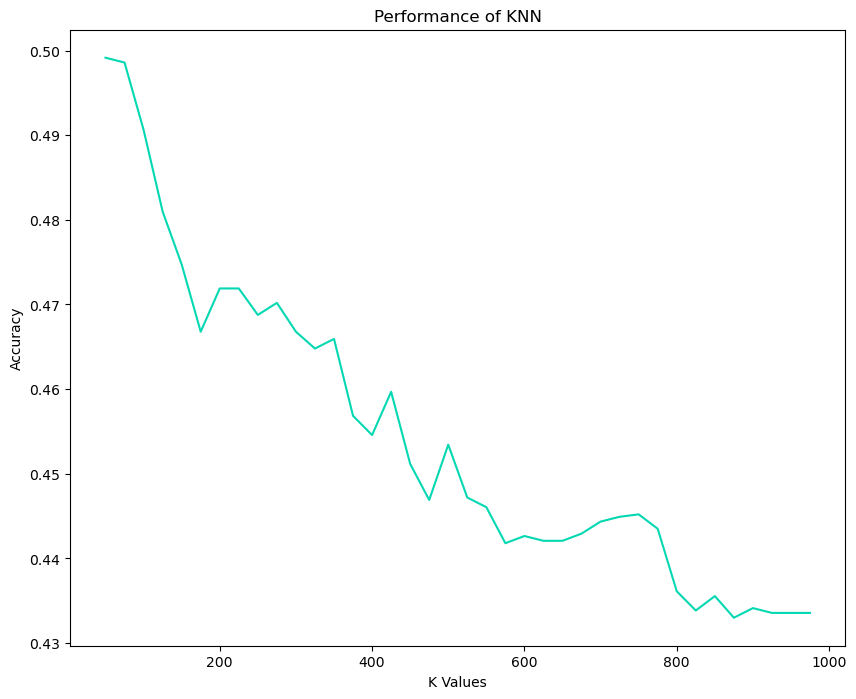

In [13]:
fig, ax = plt.subplots(1,1, figsize=(10,8))
sns.lineplot(x=k_vals, y=acc_vals, color=XKCD_COLORS["xkcd:aquamarine"], ax=ax)
ax.set_xlabel("K Values")
ax.set_ylabel("Accuracy")
ax.set_title("Performance of KNN")

In [15]:
np.where(acc_vals==acc_vals.max())

(array([0]),)

In [22]:
model_2 = KNeighborsClassifier(n_neighbors=50).fit(X_train,y_train)
y_m2 = model_2.predict(X_test)
acc_m2 = accuracy_score(y_test, y_m2)

In [23]:
print(classification_report(y_test, y_m2))

              precision    recall  f1-score   support

           1       0.96      0.85      0.90       379
           2       0.40      0.34      0.37       941
           3       0.46      0.29      0.35       964
           4       0.47      0.68      0.56      1238

    accuracy                           0.50      3522
   macro avg       0.57      0.54      0.54      3522
weighted avg       0.50      0.50      0.49      3522



Looks like 50 nearest neighbors works best.  However, to make sure it's not actually a lower number, we should check everything before 50 as well.

In [18]:
k_vals = np.arange(5,60,1)
acc_vals = np.zeros(len(k_vals))

for i,k in enumerate(k_vals):
    model = KNeighborsClassifier(n_neighbors=k).fit(X_train,y_train)
    y_m = model.predict(X_test)
    acc_vals[i] = accuracy_score(y_test, y_m)

Text(0.5, 1.0, 'Performance of KNN')

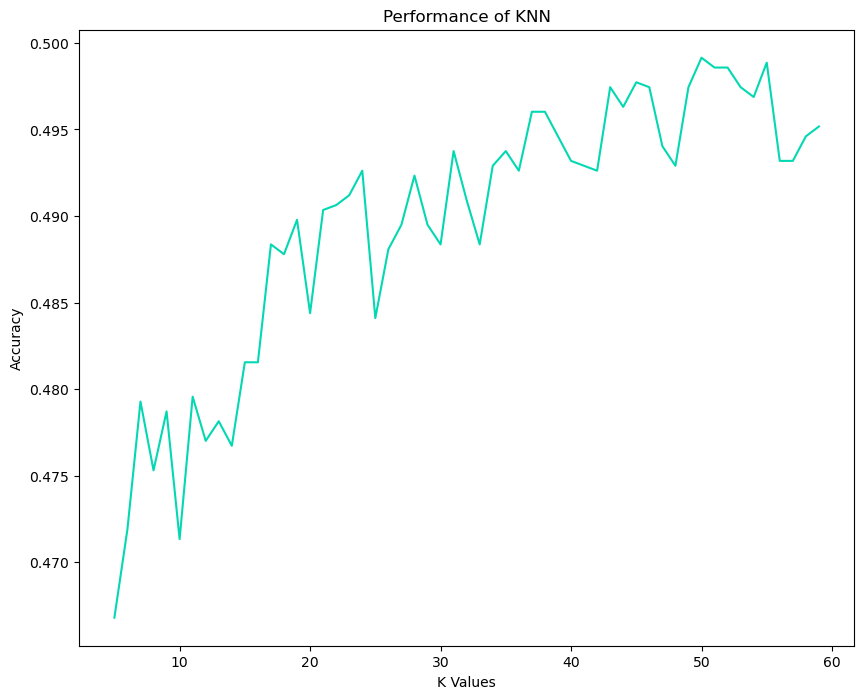

In [19]:
fig, ax = plt.subplots(1,1, figsize=(10,8))
sns.lineplot(x=k_vals, y=acc_vals, color=XKCD_COLORS["xkcd:aquamarine"], ax=ax)
ax.set_xlabel("K Values")
ax.set_ylabel("Accuracy")
ax.set_title("Performance of KNN")

In [20]:
k_vals[np.where(acc_vals==acc_vals.max())]

array([50])

In [21]:
acc_vals.max()

np.float64(0.4991482112436116)

So, an accuracy of about 50% is actually surprisingly good given how messy this dataset remains. Let's also check and see if removing scantimes is helpful.  

In [25]:
X_train, X_test, y_train, y_test = train_test_split(x.drop(columns=['scan_time']), y, test_size=0.3, random_state=42)

In [26]:
model_3 = KNeighborsClassifier(n_neighbors=50).fit(X_train,y_train)
y_m3 = model_3.predict(X_test)
acc_m3 = accuracy_score(y_test, y_m3)

In [27]:
print(classification_report(y_test, y_m3))

              precision    recall  f1-score   support

           1       0.40      0.55      0.46       379
           2       0.24      0.15      0.18       941
           3       0.26      0.08      0.12       964
           4       0.37      0.63      0.46      1238

    accuracy                           0.34      3522
   macro avg       0.32      0.35      0.31      3522
weighted avg       0.31      0.34      0.29      3522



So, it turns out scan time matters somehow. Let's drop the two other groups and consider only indoor and outdoor.

In [31]:
x = fdf[(fdf['target_numeric']!=1) & (fdf['target_numeric']!=4)]
y = x.target_numeric
x = x.drop(['target', 'target_numeric', 'scan_time'], axis=1)
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

In [33]:
model_4 = KNeighborsClassifier(n_neighbors=50).fit(X_train,y_train)
y_m4 = model_4.predict(X_test)
acc_m4 = accuracy_score(y_test, y_m4)

In [34]:
print(classification_report(y_test, y_m4))

              precision    recall  f1-score   support

           2       0.50      0.63      0.56       936
           3       0.49      0.36      0.42       913

    accuracy                           0.50      1849
   macro avg       0.50      0.50      0.49      1849
weighted avg       0.50      0.50      0.49      1849



In [36]:
x = fdf[(fdf['target_numeric']!=1) & (fdf['target_numeric']!=4)]
y = x.target_numeric
x = x.drop(['target', 'target_numeric'], axis=1)
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

In [37]:
model_5 = KNeighborsClassifier(n_neighbors=50).fit(X_train,y_train)
y_m5 = model_5.predict(X_test)
acc_m5 = accuracy_score(y_test, y_m5)

In [38]:
print(classification_report(y_test, y_m5))

              precision    recall  f1-score   support

           2       0.61      0.68      0.64       936
           3       0.63      0.56      0.59       913

    accuracy                           0.62      1849
   macro avg       0.62      0.62      0.61      1849
weighted avg       0.62      0.62      0.62      1849



Let's do some dimensionality reduction. 

In [88]:
from sklearn.decomposition import PCA

In [89]:
pca = PCA()
pca_x_norm = pca.fit_transform(x)

In [90]:
exp_var = pca.explained_variance_ratio_

In [91]:
cum_exp_var = np.zeros(exp_var.shape[0])
for i in range(exp_var.shape[0]):
    cum_exp_var[i] = exp_var[:i].sum()

Text(0, 0.5, 'Cumulative Variance Explained')

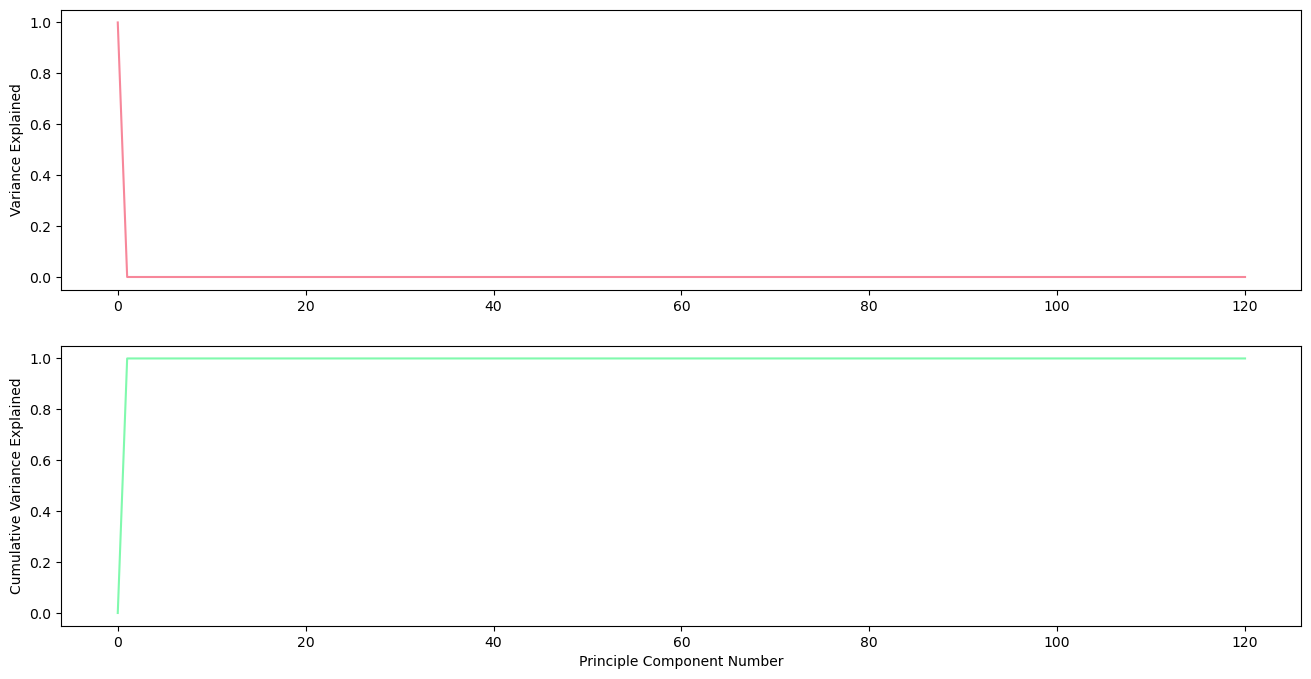

In [92]:
fig, ax = plt.subplots(2,1, figsize=(16,8))
sns.lineplot(x=np.arange(exp_var.shape[0]), y=exp_var, color=XKCD_COLORS["xkcd:rose pink"], ax=ax[0])
sns.lineplot(x=np.arange(exp_var.shape[0]), y=cum_exp_var, color=XKCD_COLORS["xkcd:seafoam"], ax=ax[1])
ax[1].set_xlabel("Principle Component Number")
ax[0].set_ylabel("Variance Explained")
ax[1].set_ylabel("Cumulative Variance Explained")

In [94]:
exp_var[:10]

array([9.99999955e-01, 1.29408219e-08, 7.35482430e-09, 6.18281346e-09,
       4.58590696e-09, 3.00294752e-09, 2.02104811e-09, 1.60909049e-09,
       1.26264249e-09, 1.00990392e-09])

We can come to the conclusion that we need about the first thirty or so principle components to have the same information as the entire dataset. Let's use this going forward.

---

Now let's make an attempt at using the same model, but let's try dropping the nontask data as that's totally useless, honestly.

In [116]:
fdf_truncated = fdf[fdf['target_numeric']!=1]
xt = fdf_truncated.drop(['target', 'target_numeric'], axis=1)
# x_norm = StandardScaler().fit_transform(x)
yt = fdf_truncated['target_numeric']

In [117]:
pca = PCA(1)
x_norm_pc = pca.fit_transform(xt)
pca.explained_variance_ratio_.sum()

np.float64(0.9999999391251271)

In [118]:
X_train, X_test, y_train, y_test = train_test_split(x_norm_pc, yt, test_size=0.3, random_state=42)

In [119]:
model_2 = KNeighborsClassifier(n_neighbors=79).fit(X_train,y_train)
y_m2 = model_2.predict(X_test)
acc_m2 = accuracy_score(y_test, y_m2)

In [120]:
acc_m2

0.45710627400768244

Alright, so I take that back. Clearly, it helped the algorithm somehow. However, for thoroughness, we should make sure it's not because the best k is now different.

In [121]:
k_vals = np.arange(50,1000,25)
acc_vals = np.zeros(len(k_vals))

for i,k in enumerate(k_vals):
    model = KNeighborsClassifier(n_neighbors=k).fit(X_train,y_train)
    y_m = model.predict(X_test)
    acc_vals[i] = accuracy_score(y_test, y_m)

Text(0.5, 1.0, 'Performance of KNN')

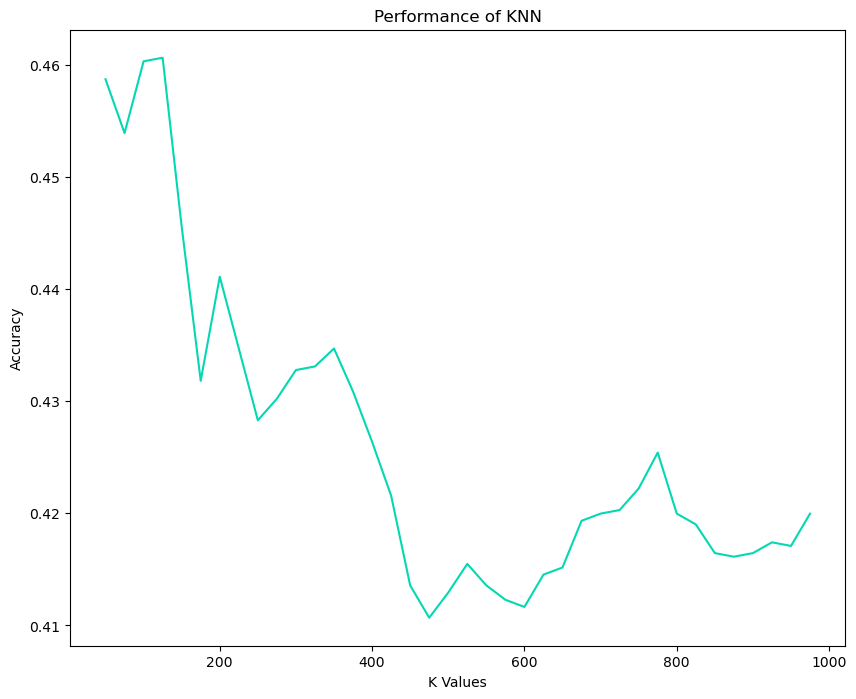

In [122]:
fig, ax = plt.subplots(1,1, figsize=(10,8))
sns.lineplot(x=k_vals, y=acc_vals, color=XKCD_COLORS["xkcd:aquamarine"], ax=ax)
ax.set_xlabel("K Values")
ax.set_ylabel("Accuracy")
ax.set_title("Performance of KNN")

In [123]:
print(f"The maximum accuracy we've reached is {acc_vals.max()*100}.")

The maximum accuracy we've reached is 46.06274007682458.


Well, what do you know?  Let's take a closer look at this peak at around k=200. I don't expect anything, but I am curious to see what a smoother curve in that region might look like, so let's give that a shot.

In [71]:
k_vals = np.arange(10,200,5)
acc_vals = np.zeros(len(k_vals))

for i,k in enumerate(k_vals):
    model = KNeighborsClassifier(n_neighbors=k).fit(X_train,y_train)
    y_m = model.predict(X_test)
    acc_vals[i] = accuracy_score(y_test, y_m)

Text(0.5, 1.0, 'Performance of KNN')

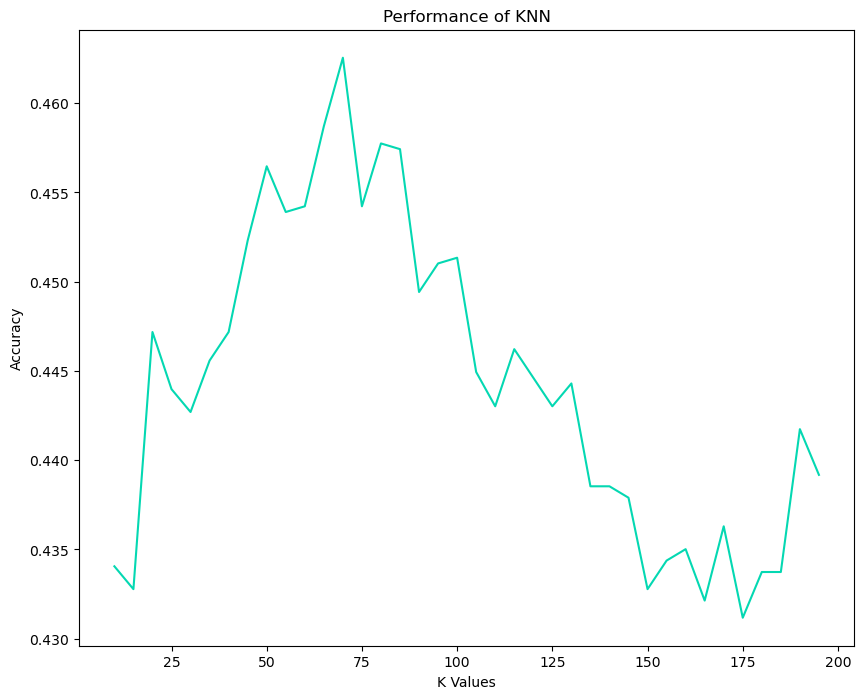

In [72]:
fig, ax = plt.subplots(1,1, figsize=(10,8))
sns.lineplot(x=k_vals, y=acc_vals, color=XKCD_COLORS["xkcd:aquamarine"], ax=ax)
ax.set_xlabel("K Values")
ax.set_ylabel("Accuracy")
ax.set_title("Performance of KNN")

In [73]:
print(f"The maximum accuracy we've reached is {acc_vals.max()*100}.")

The maximum accuracy we've reached is 46.25480153649168.


In [74]:
k_vals = np.arange(50,100,1)
acc_vals = np.zeros(len(k_vals))

for i,k in enumerate(k_vals):
    model = KNeighborsClassifier(n_neighbors=k).fit(X_train,y_train)
    y_m = model.predict(X_test)
    acc_vals[i] = accuracy_score(y_test, y_m)

Text(0.5, 1.0, 'Performance of KNN')

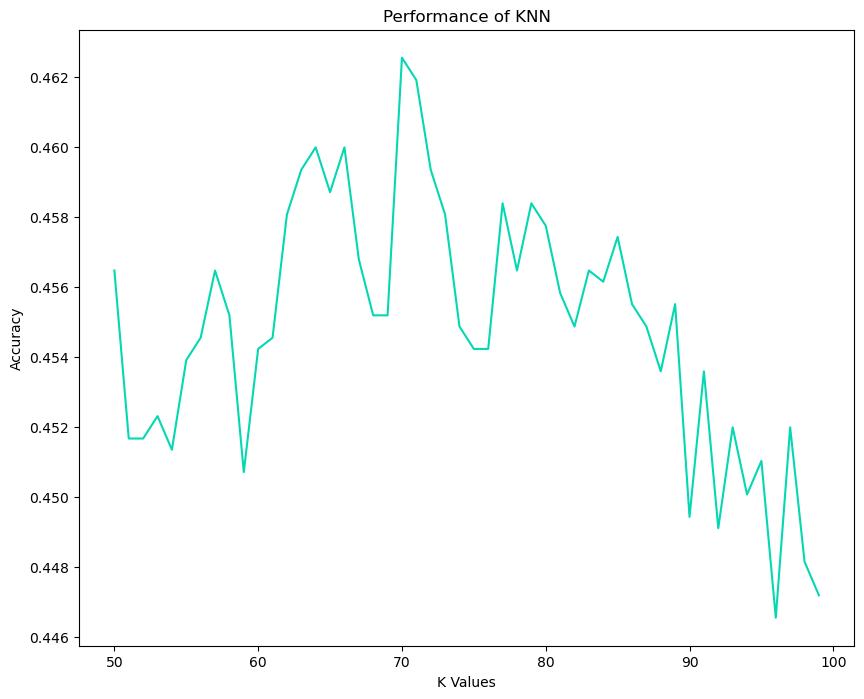

In [75]:
fig, ax = plt.subplots(1,1, figsize=(10,8))
sns.lineplot(x=k_vals, y=acc_vals, color=XKCD_COLORS["xkcd:aquamarine"], ax=ax)
ax.set_xlabel("K Values")
ax.set_ylabel("Accuracy")
ax.set_title("Performance of KNN")

In [76]:
print(f"The maximum accuracy we've reached is {acc_vals.max()*100}.")

The maximum accuracy we've reached is 46.25480153649168.


Nevermind, this is actually worse and I take back nothing!